## Financial Data Analysis and Visualization of State Bank of India (SBI)
**Selected Business Area:** Banking & Financial Performance  
**Tools Used:** Pandas, NumPy, Matplotlib, Seaborn  
**Dataset Source:** [Screener.in — State Bank of India](https://www.screener.in/company/SBIN/consolidated/) (SBI Audited Regulatory Filings)


In [ ]:
# Section 1: Importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Setting visual grid style
sns.set_theme(style='whitegrid')
print("Libraries imported successfully.")


Libraries imported successfully.


In [ ]:
# Section 2: Connecting to Google Drive and loading the dataset

import os
import pandas as pd

# Mount Google Drive to access SBI.xlsx
from google.colab import drive
drive.mount('/content/drive')

# File path to SBI.xlsx in Google Drive
file_path = '/content/drive/MyDrive/Colab Notebooks/SBI.xlsx'

# Check if file exists in current folder (fallback)
if not os.path.exists(file_path):
    file_path = 'SBI.xlsx'

# Loading the 10-year Profit and Loss table from the Data Sheet using Pandas read_excel
df = pd.read_excel(file_path, sheet_name='Data Sheet', skiprows=15, nrows=15)

# Viewing raw data loaded
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Report Date,2017-03-31 00:00:00,2018-03-31 00:00:00,2019-03-31 00:00:00,2020-03-31 00:00:00,2021-03-31 00:00:00,2022-03-31 00:00:00,2023-03-31 00:00:00,2024-03-31 00:00:00,2025-03-31 00:00:00,2026-03-31 00:00:00
0,Sales,230447.10,228970.28,253322.17,269851.66,278115.48,289972.69,350844.58,439188.51,490312.7,514932.59
1,Raw Material Cost,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Change in Inventory,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Power and Fuel,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Other Mfr. Exp,870.96,971.90,1057.77,1121.27,1116.50,1219.04,1305.59,1448.83,1553.6,1684.95


In [ ]:
# Section 3: Data cleaning and reshaping using Pandas

# Transposing table so years become rows and metrics become columns
df = df.set_index('Report Date').T.reset_index()

# Renaming index column to Date
df.rename(columns={'index': 'Date'}, inplace=True)

# Extracting Year from Date
df['Year'] = pd.to_datetime(df['Date']).dt.year

# Dropping unnecessary non-banking manufacturing columns
df.drop(columns=['Date', 'Raw Material Cost', 'Change in Inventory', 'Power and Fuel'], errors='ignore', inplace=True)

# Converting financial metrics to numeric float values
numeric_columns = ['Sales', 'Other Income', 'Interest', 'Employee Cost', 'Selling and admin', 'Other Expenses', 'Depreciation', 'Profit before tax', 'Tax', 'Net profit']
for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Viewing the cleaned dataset
df.head()


Report Date,Sales,Other Mfr. Exp,Employee Cost,Selling and admin,Other Expenses,Other Income,Depreciation,Interest,Profit before tax,Tax,Net profit,Dividend Amount,Year
0,230447.10,870.96,35700.74,10596.89,98497.50,68193.17,2914.68,149114.67,944.83,1335.50,241.23,2073.11,2017
1,228970.28,971.90,35417.16,12597.96,120077.51,77557.39,3105.07,146602.98,-12244.91,-8057.50,-4556.29,NaN,2018
2,253322.17,1057.77,43804.72,12823.59,108417.44,77365.19,3495.89,155867.46,5220.49,2151.41,2299.64,NaN,2019
3,269851.66,1121.27,48861.70,13665.28,109260.45,98158.99,3661.56,161123.80,30316.59,12139.76,19767.80,NaN,2020
4,278115.48,1116.50,54344.09,14050.25,123309.85,107222.41,3711.06,156010.17,32795.97,8516.25,22405.46,3569.84,2021


In [ ]:
# Section 4: Inspecting the dataset using basic Pandas functions

# Checking dimensions of dataset (rows, columns)
print("Dataset Shape (Rows, Columns):", df.shape)

# Checking data types and non-null values
df.info()

# Checking for missing values per column
print("Missing values in each column:")
print(df.isnull().sum())

# Summary statistics of core financial metrics (in Rs Crore)
df[['Sales', 'Other Income', 'Interest', 'Employee Cost', 'Net profit']].describe()


Dataset Shape (Rows, Columns): (10, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Sales              10 non-null     float64
 1   Other Mfr. Exp     10 non-null     float64
 2   Employee Cost      10 non-null     float64
 3   Selling and admin  10 non-null     float64
 4   Other Expenses     10 non-null     float64
 5   Other Income       10 non-null     float64
 6   Depreciation       10 non-null     float64
 7   Interest           10 non-null     float64
 8   Profit before tax  10 non-null     float64
 9   Tax                10 non-null     float64
 10  Net profit         10 non-null     float64
 11  Dividend Amount    7 non-null      float64
 12  Year               10 non-null     int32  
dtypes: float64(12), int32(1)
memory usage: 1.1 KB
Missing values in each column:
Report Date
Sales                0
Other Mfr. Exp       

Report Date,Sales,Other Income,Interest,Employee Cost,Net profit
count,10.000000,10.000000,10.000000,10.000000,10.000000
mean,334595.776000,119415.906000,199057.844000,56840.455000,35912.468000
std,108502.394181,43536.427461,66524.186772,16166.103499,33039.798665
min,228970.280000,68193.170000,146602.980000,35417.160000,-4556.290000
25%,257454.542500,82707.790000,155903.137500,45068.965000,6666.680000
50%,284044.085000,112111.405000,158659.070000,57901.025000,28889.670000
75%,417102.527500,147173.182500,242297.242500,68291.720000,64225.545000
max,514932.590000,197710.940000,315004.810000,83686.610000,83298.780000


In [ ]:
# Section 5: Basic Data Analysis and Ratio Calculations using Pandas & NumPy

import numpy as np

# 1. Total Income (Interest Earned/Sales + Other Income)
df['Total_Income'] = df['Sales'] + df['Other Income']

# 2. Operating Expenses (Employee Cost + Selling/Admin + Other Operating Expenses)
df['Operating_Expenses'] = df['Employee Cost'] + df['Selling and admin'] + df['Other Expenses']

# 3. Total Expenses (Interest Expended + Operating Expenses + Depreciation)
df['Total_Expenses'] = df['Interest'] + df['Operating_Expenses'] + df['Depreciation']

# 4. Net Interest Income (NII = Sales/Interest Earned - Interest Expended)
df['Net_Interest_Income'] = df['Sales'] - df['Interest']

# 5. Cost-to-Income Ratio (%)
df['Cost_to_Income_Ratio_%'] = (df['Operating_Expenses'] / df['Total_Income']) * 100

# 6. Net Profit Margin (%)
df['Net_Profit_Margin_%'] = (df['Net profit'] / df['Total_Income']) * 100

# 7. 10-Year Revenue CAGR using NumPy
years = len(df) - 1
cagr_revenue = (np.power((df['Total_Income'].iloc[-1] / df['Total_Income'].iloc[0]), (1 / years)) - 1) * 100
print("10-Year Revenue CAGR (%):", round(cagr_revenue, 2))

# 8. Average Cost-to-Income Ratio using NumPy
avg_cost_ratio = np.mean(df['Cost_to_Income_Ratio_%'])
print("Average Cost-to-Income Ratio (%):", round(avg_cost_ratio, 2))

# Displaying calculated business metrics table for all 10 years
df[['Year', 'Total_Income', 'Net_Interest_Income', 'Operating_Expenses', 'Total_Expenses', 'Net profit', 'Cost_to_Income_Ratio_%', 'Net_Profit_Margin_%']]

10-Year Revenue CAGR (%): 10.15
Average Cost-to-Income Ratio (%): 45.75


Report Date,Year,Total_Income,Net_Interest_Income,Operating_Expenses,Total_Expenses,Net profit,Cost_to_Income_Ratio_%,Net_Profit_Margin_%
0,2017,298640.27,81332.43,144795.13,296824.48,241.23,48.484797,0.080776
1,2018,306527.67,82367.30,168092.63,317800.68,-4556.29,54.837669,-1.486420
2,2019,330687.36,97454.71,165045.75,324409.10,2299.64,49.909906,0.695412
3,2020,368010.65,108727.86,171787.43,336572.79,19767.80,46.680016,5.371529
4,2021,385337.89,122105.31,191704.19,351425.42,22405.46,49.749634,5.814497
5,2022,406973.09,133778.35,196129.81,356015.42,35373.88,48.192329,8.691946
6,2023,473378.14,160863.76,202997.57,396673.99,55648.17,42.882751,11.755543
7,2024,594574.90,179452.46,238300.85,501886.02,67084.67,40.079198,11.282795
8,2025,663343.32,189369.36,250489.61,555424.43,77561.34,37.761684,11.692488
9,2026,712643.53,199927.78,277096.07,596930.60,83298.78,38.882844,11.688702


## Section 6: Data Visualizations (Matplotlib & Seaborn)


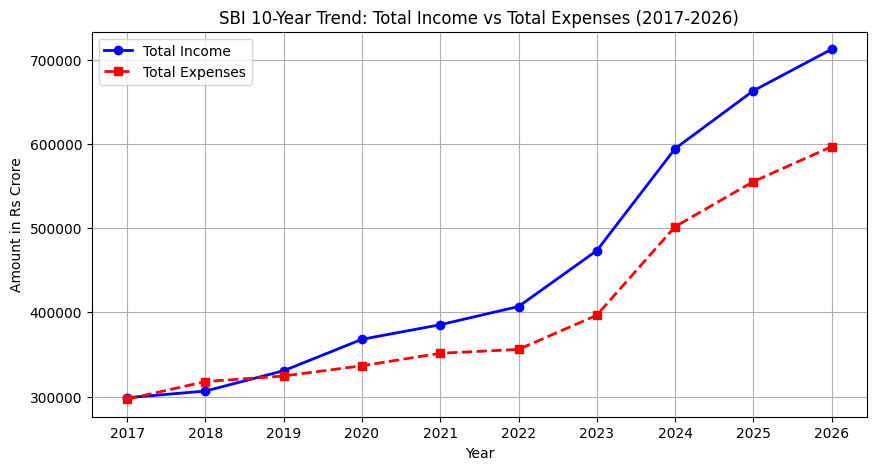

In [ ]:
# Chart 1: Line plot for Total Income vs Total Expenses (2017 to 2026)
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))

# Plotting Total Income
plt.plot(df['Year'], df['Total_Income'], marker='o', color='blue', linewidth=2, label='Total Income')

# Plotting Total Expenses
plt.plot(df['Year'], df['Total_Expenses'], marker='s', color='red', linewidth=2, linestyle='--', label='Total Expenses')

# Formatting chart
plt.title('SBI 10-Year Trend: Total Income vs Total Expenses (2017-2026)')
plt.xlabel('Year')
plt.ylabel('Amount in Rs Crore')
plt.xticks(df['Year'])
plt.legend()
plt.grid(True)

plt.show()


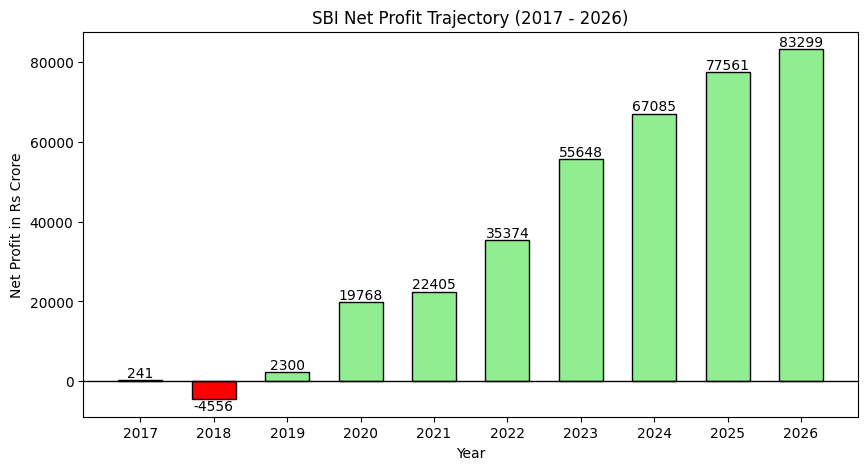

In [ ]:
# Chart 2: Bar chart for Net Profit (Highlighting 2018 loss vs 2019-2026 recovery)
plt.figure(figsize=(10, 5))

# Condition for bar colors: Red for loss (2018), Lightgreen for profit
colors = ['red' if x < 0 else 'lightgreen' for x in df['Net profit']]

# Plotting bar chart
bars = plt.bar(df['Year'], df['Net profit'], color=colors, edgecolor='black', width=0.6)

# Adding data labels on top of bars
plt.bar_label(bars, fmt='%.0f')

# Zero reference line
plt.axhline(0, color='black', linewidth=1)

# Formatting chart
plt.title('SBI Net Profit Trajectory (2017 - 2026)')
plt.xlabel('Year')
plt.ylabel('Net Profit in Rs Crore')
plt.xticks(df['Year'])

plt.show()


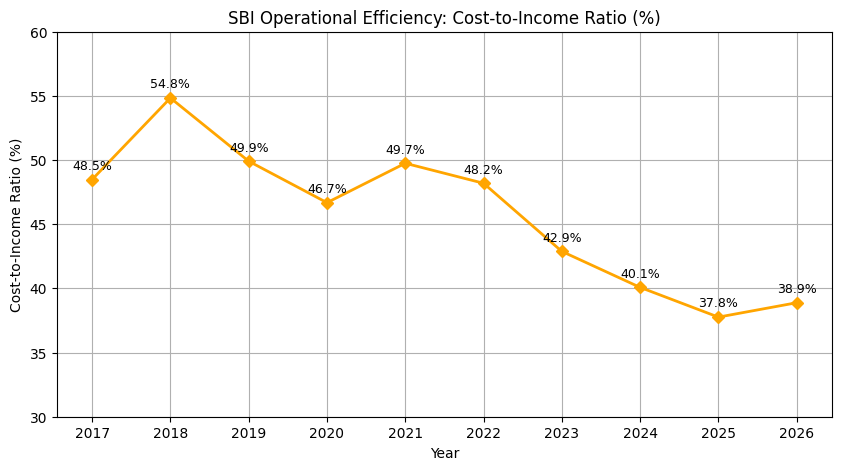

In [ ]:
# Chart 3: Line plot showing operational efficiency (Cost-to-Income Ratio %)
plt.figure(figsize=(10, 5))

# Plotting line chart
plt.plot(df['Year'], df['Cost_to_Income_Ratio_%'], marker='D', color='orange', linewidth=2)

# Adding percentage labels on data points
for x, y in zip(df['Year'], df['Cost_to_Income_Ratio_%']):
    plt.text(x, y + 0.8, f'{y:.1f}%', ha='center', fontsize=9)

# Formatting chart
plt.title('SBI Operational Efficiency: Cost-to-Income Ratio (%)')
plt.xlabel('Year')
plt.ylabel('Cost-to-Income Ratio (%)')
plt.xticks(df['Year'])
plt.ylim(30, 60)
plt.grid(True)

plt.show()


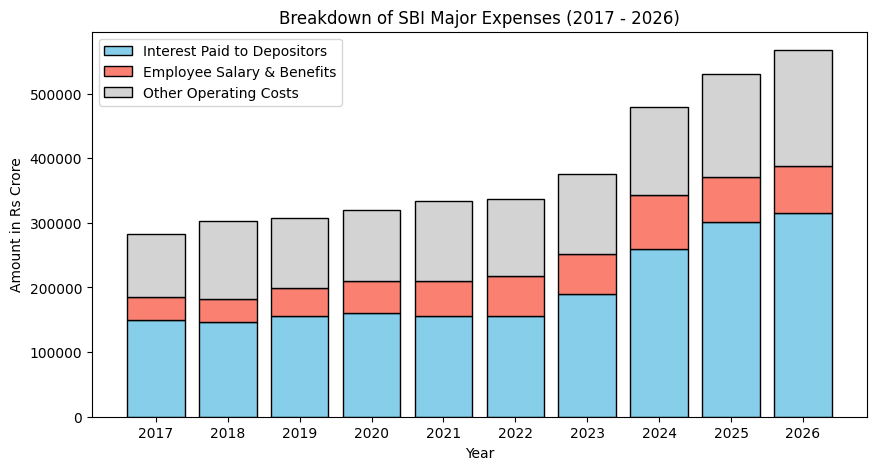

In [ ]:
# Chart 4: Stacked bar chart showing breakdown of major expenses
plt.figure(figsize=(10, 5))

# Plotting stacked bars for major expenses
plt.bar(df['Year'], df['Interest'], label='Interest Paid to Depositors', color='skyblue', edgecolor='black')
plt.bar(df['Year'], df['Employee Cost'], bottom=df['Interest'], label='Employee Salary & Benefits', color='salmon', edgecolor='black')
plt.bar(df['Year'], df['Other Expenses'], bottom=df['Interest'] + df['Employee Cost'], label='Other Operating Costs', color='lightgray', edgecolor='black')

# Formatting chart
plt.title('Breakdown of SBI Major Expenses (2017 - 2026)')
plt.xlabel('Year')
plt.ylabel('Amount in Rs Crore')
plt.xticks(df['Year'])
plt.legend()

plt.show()


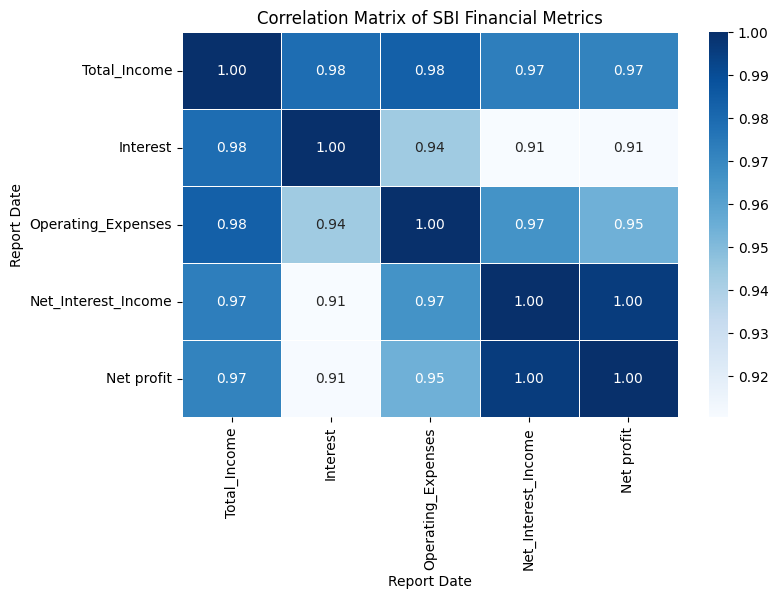

In [ ]:
# Chart 5: Correlation Heatmap between key financial variables
# Selecting key numerical columns
import seaborn as sns
cols = ['Total_Income', 'Interest', 'Operating_Expenses', 'Net_Interest_Income', 'Net profit']
corr_matrix = df[cols].corr()

plt.figure(figsize=(8, 5))

# Plotting heatmap using Seaborn
sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt='.2f', linewidths=0.5)

# Formatting chart
plt.title('Correlation Matrix of SBI Financial Metrics')

plt.show()
